In [106]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import SimpleITK as sitk
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from NoduleDS import NoduleDataset
from torch.optim.lr_scheduler import OneCycleLR

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [107]:
BATCH_SIZE = 16
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224
NUM_WORKERS = 4
WEIGHT_DECAY = 0.01

# Paths - using pre-split data to avoid leakage
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"

train_images_path = os.path.join(split_base_path, "train", "images")
val_images_path = os.path.join(split_base_path, "val", "images")
test_images_path = os.path.join(split_base_path, "test", "images")

train_csv_path = os.path.join(split_base_path, "train", "metadata_no_aug.csv")
val_csv_path = os.path.join(split_base_path, "val", "metadata_val.csv")
test_csv_path = os.path.join(split_base_path, "test", "metadata_test.csv")

train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

In [108]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    #transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(degrees=3),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [109]:
# Create datasets - each pointing to its own split directory
train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=True)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=True)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=True)

In [110]:
# %% Calculate class weights for imbalanced dataset
print("\nCalculating class weights for imbalanced dataset...")

# Count class distribution in training set
train_labels = train_df['label'].values
class_counts = np.bincount(train_labels)
print(f"Training set distribution:")
print(f"  Class 0 (No Nodule): {class_counts[0]} samples")
print(f"  Class 1 (Nodule): {class_counts[1]} samples")

# Calculate weights: inverse of class frequency
total_samples = len(train_labels)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"\nCalculated class weights:")
print(f"  Class 0 weight: {class_weights[0]:.4f}")
print(f"  Class 1 weight: {class_weights[1]:.4f}")


Calculating class weights for imbalanced dataset...
Training set distribution:
  Class 0 (No Nodule): 2623 samples
  Class 1 (Nodule): 1034 samples

Calculated class weights:
  Class 0 weight: 0.6971
  Class 1 weight: 1.7684


In [111]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class ResNetWithAttentionSupervision(nn.Module):
    """ResNet-50 with attention map supervision for WSOL"""
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        
        backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.act1, backbone.maxpool)
        self.stage1 = backbone.layer1  # 256ch, 56×56
        self.stage2 = backbone.layer2  # 512ch, 28×28
        self.stage3 = backbone.layer3  # 1024ch, 14×14
        self.stage4 = backbone.layer4  # 2048ch, 7×7
        
        # Classification head
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(2048, num_classes)
        
        # ===== ATTENTION MAP GENERATION =====
        # Generate attention from high-level features (stage4)
        self.attention_conv = nn.Sequential(
            nn.Conv2d(2048, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 1, kernel_size=1),  # Single channel attention map
            nn.Sigmoid()  # [0, 1] attention weights
        )
        
    def forward(self, x, return_attention=False):
        B = x.shape[0]
        original_size = x.shape[-2:]  # (224, 224)
        
        # Backbone
        x = self.stem(x)
        c2 = self.stage1(x)
        c3 = self.stage2(c2)
        c4 = self.stage3(c3)
        c5 = self.stage4(c4)  # [B, 2048, 7, 7]
        
        # Classification
        pooled = self.global_pool(c5)
        class_logits = self.classifier(pooled.flatten(1))
        
        # Generate attention map from C5
        attention_map = self.attention_conv(c5)  # [B, 1, 7, 7]
        
        # Upsample attention map to original image size for visualization/loss
        attention_map_upsampled = F.interpolate(
            attention_map, 
            size=original_size,  # (224, 224)
            mode='bilinear', 
            align_corners=False
        )
        
        if return_attention:
            return class_logits, attention_map_upsampled
        else:
            return class_logits, attention_map_upsampled


In [112]:
# Initialize model
print("\nInitializing ResNet-50 with Attention Supervision (WSOL)...")
model = ResNetWithAttentionSupervision(num_classes=2, pretrained=False)

# Load pretrained weights
print("Loading pretrained ResNet-50 weights...")
checkpoint = torch.load('./resnet50_binary.pth')
pretrained_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint

model_dict = model.state_dict()
pretrained_dict_filtered = {}

for k, v in pretrained_dict.items():
    if k.startswith('conv1'):
        pretrained_dict_filtered['stem.0.' + k] = v
    elif k.startswith('bn1'):
        pretrained_dict_filtered['stem.1.' + k] = v
    elif k.startswith('layer1'):
        pretrained_dict_filtered['stage1.' + k[7:]] = v
    elif k.startswith('layer2'):
        pretrained_dict_filtered['stage2.' + k[7:]] = v
    elif k.startswith('layer3'):
        pretrained_dict_filtered['stage3.' + k[7:]] = v
    elif k.startswith('layer4'):
        pretrained_dict_filtered['stage4.' + k[7:]] = v
    elif k.startswith('fc'):
        pretrained_dict_filtered['classifier.' + k[3:]] = v

model_dict.update(pretrained_dict_filtered)
model.load_state_dict(model_dict, strict=False)
print("✓ Loaded pretrained backbone weights")

model = model.to(device)

# Unfreeze for training
for name, param in model.named_parameters():
    if 'stem' in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\nTrainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# ===== DEFINE OPTIMIZER, SCHEDULER, AND CRITERION =====
print("\nSetting up training components...")

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                       lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer, 
    max_lr=LEARNING_RATE,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,  # Warmup for 30% of training
    anneal_strategy='cos'
)

# Loss function - Weighted Cross Entropy for imbalanced classes
criterion = nn.CrossEntropyLoss(weight=class_weights)


Initializing ResNet-50 with Attention Supervision (WSOL)...


Loading pretrained ResNet-50 weights...
✓ Loaded pretrained backbone weights

Trainable: 32,940,803 / 32,950,339 (100.0%)

Setting up training components...


In [113]:
# ==================== OPTIMIZED TRAINING FUNCTIONS (FAST VERSION) ====================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    """Fast training loop - NO prediction collection during training"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for batch in pbar:
        if len(batch) == 3:
            images, labels, bbox = batch
        else:
            images, labels = batch
        
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        # Forward pass
        logits, attention_map = model(images)
        
        # Compute classification loss
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        # Metrics (keep on GPU, minimal overhead)
        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%',
            'lr': f'{current_lr:.2e}'
        })
    
    return total_loss / len(loader), 100. * correct / total


def validate(model, loader, criterion, device):
    """Validation with prediction collection"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            if len(batch) == 3:
                images, labels, bbox = batch
            else:
                images, labels = batch
            
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Forward pass
            logits, attention_map = model(images)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            
            # Get predictions and probabilities
            probs = torch.softmax(logits, dim=1)[:, 1]
            _, predicted = torch.max(logits, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Collect for metrics (keep as tensors until end)
            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())
    
    # Convert to numpy once at the end
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()
    
    return total_loss / len(loader), 100. * correct / total, all_preds, all_labels, all_probs


def get_predictions_fast(model, loader, device):
    """Fast prediction collection for training metrics"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Collecting Train Metrics', leave=False):
            if len(batch) == 3:
                images, labels, _ = batch
            else:
                images, labels = batch
            
            images = images.to(device, non_blocking=True)
            
            logits, _ = model(images)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            
            all_preds.append(preds.cpu())
            all_labels.append(labels)
            all_probs.append(probs.cpu())
    
    return (torch.cat(all_preds).numpy(), 
            torch.cat(all_labels).numpy(), 
            torch.cat(all_probs).numpy())

In [114]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# %% FAST Training Loop (Optimized)
print("\nStarting training with attention supervision...")
history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [], 'train_precision': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_precision': []
}
best_val_acc = 0.0
best_val_auc = 0.0
best_model_path = 'best_resnet_wsod_attention.pth'

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train (FAST - no prediction collection)
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, device
    )
    
    # Validate (collects predictions)
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(
        model, val_loader, criterion, device
    )
    
    # Get training predictions ONCE per epoch (separate pass)
    train_preds, train_labels, train_probs = get_predictions_fast(model, train_loader, device)
    
    # Calculate metrics
    train_auc = roc_auc_score(train_labels, train_probs)
    train_precision = precision_score(train_labels, train_preds, average='binary', zero_division=0)
    
    val_auc = roc_auc_score(val_labels, val_probs)
    val_precision = precision_score(val_labels, val_preds, average='binary', zero_division=0)
    val_recall = recall_score(val_labels, val_preds, average='binary', zero_division=0)
    val_f1 = f1_score(val_labels, val_preds, average='binary', zero_division=0)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_precision'].append(train_precision)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_precision'].append(val_precision)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%, AUC: {train_auc:.4f}, Precision: {train_precision:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, AUC: {val_auc:.4f}")
    print(f"Val Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
    print(f"Current LR: {current_lr:.2e}")
    
    # Save best model
    if val_acc > best_val_acc or (val_acc == best_val_acc and val_auc > best_val_auc):
        best_val_acc = val_acc
        best_val_auc = val_auc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_auc': val_auc,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
            'train_loss': train_loss,
        }, best_model_path)
        print(f"✓ Saved best model (Val Acc: {val_acc:.2f}%, Val AUC: {val_auc:.4f})")

print("\nTraining completed!")
print(f"Best Val Acc: {best_val_acc:.2f}%, Best Val AUC: {best_val_auc:.4f}")


Starting training with attention supervision...

Epoch 1/25
--------------------------------------------------


Training:   0%|          | 0/229 [00:00<?, ?it/s]

Training:  10%|▉         | 22/229 [02:17<21:31,  6.24s/it, loss=4.3470, acc=56.53%, lr=4.04e-06] 


KeyboardInterrupt: 

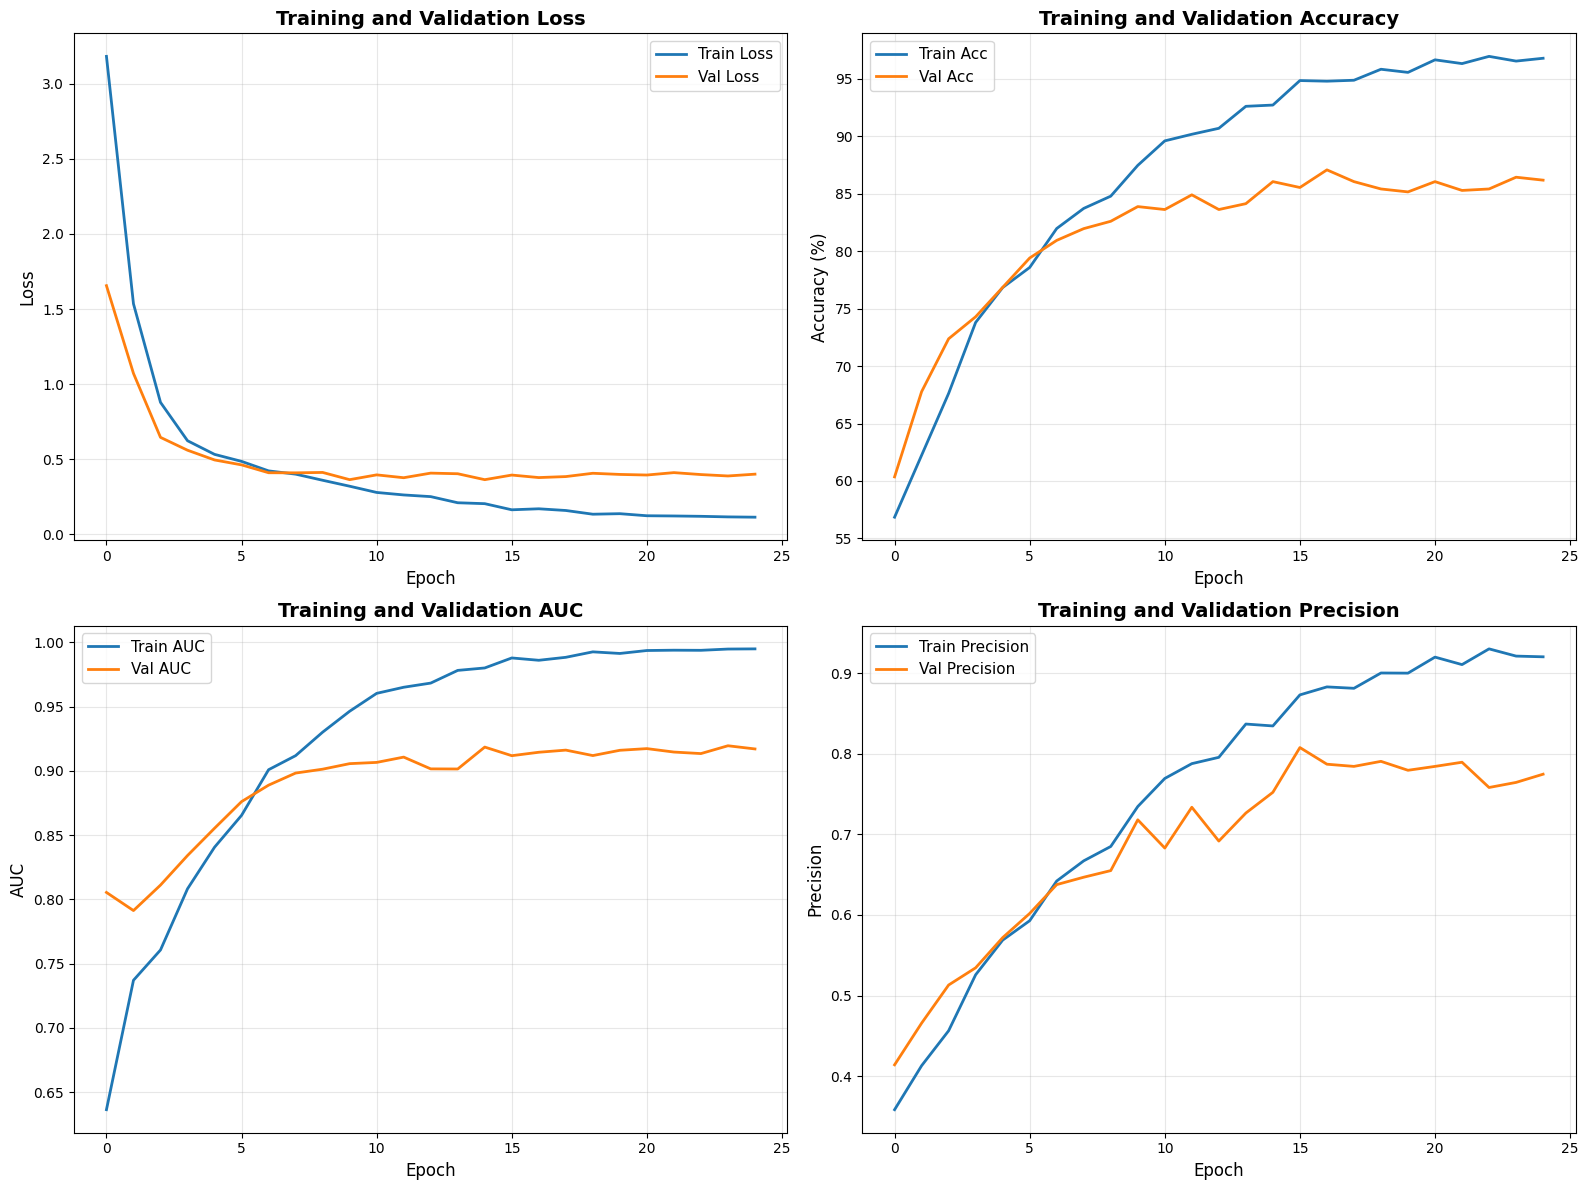

In [ ]:
# %% Plot Training History
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# AUC plot
ax3.plot(history['train_auc'], label='Train AUC', linewidth=2)
ax3.plot(history['val_auc'], label='Val AUC', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('AUC', fontsize=12)
ax3.set_title('Training and Validation AUC', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Precision plot
ax4.plot(history['train_precision'], label='Train Precision', linewidth=2)
ax4.plot(history['val_precision'], label='Val Precision', linewidth=2)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Training and Validation Precision', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# %% Load Best Model and Evaluate on Test Set
print("\nLoading best model for testing...")
#checkpoint = torch.load(best_model_path)
#model.load_state_dict(checkpoint['model_state_dict'])
    # Validate - updated to unpack all 9 return values
    
test_loss, test_acc, test_preds, test_labels, test_probs, test_precision, test_recall, test_f1, test_auc, test_att_loss = validate(model, test_loader, criterion_cls, criterion_attention, device, ATTENTION_LOSS_WEIGHT)
print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['No Nodule', 'Nodule']))

# ROC AUC Score
auc = roc_auc_score(test_labels, test_probs)
print(f"\nROC AUC Score: {auc:.4f}")


Loading best model for testing...


Validation: 100%|██████████| 50/50 [00:12<00:00,  3.87it/s]


Test Results:
Test Loss: 0.4151
Test Accuracy: 83.57%

Classification Report:
              precision    recall  f1-score   support

   No Nodule       0.88      0.89      0.89       568
      Nodule       0.71      0.68      0.70       217

    accuracy                           0.84       785
   macro avg       0.80      0.79      0.79       785
weighted avg       0.83      0.84      0.83       785


ROC AUC Score: 0.9035


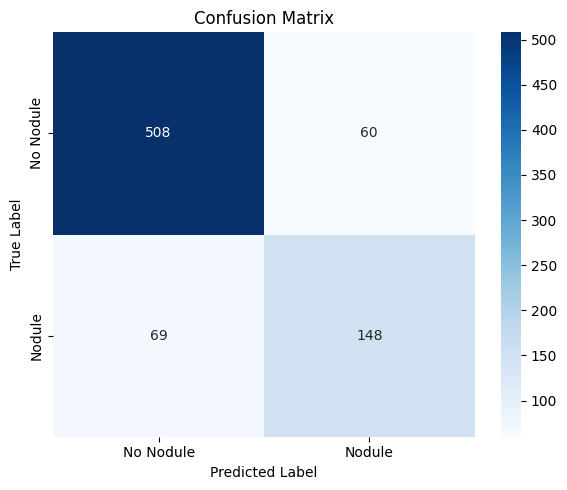

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_labels = ['No Nodule', 'Nodule']

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


VISUALIZING ATTENTION HEATMAPS ON TRAINING SET

Attention map stats for sample 2650:
  Min: 0.000000
  Max: 0.030963
  Mean: 0.002125
  Std: 0.003568


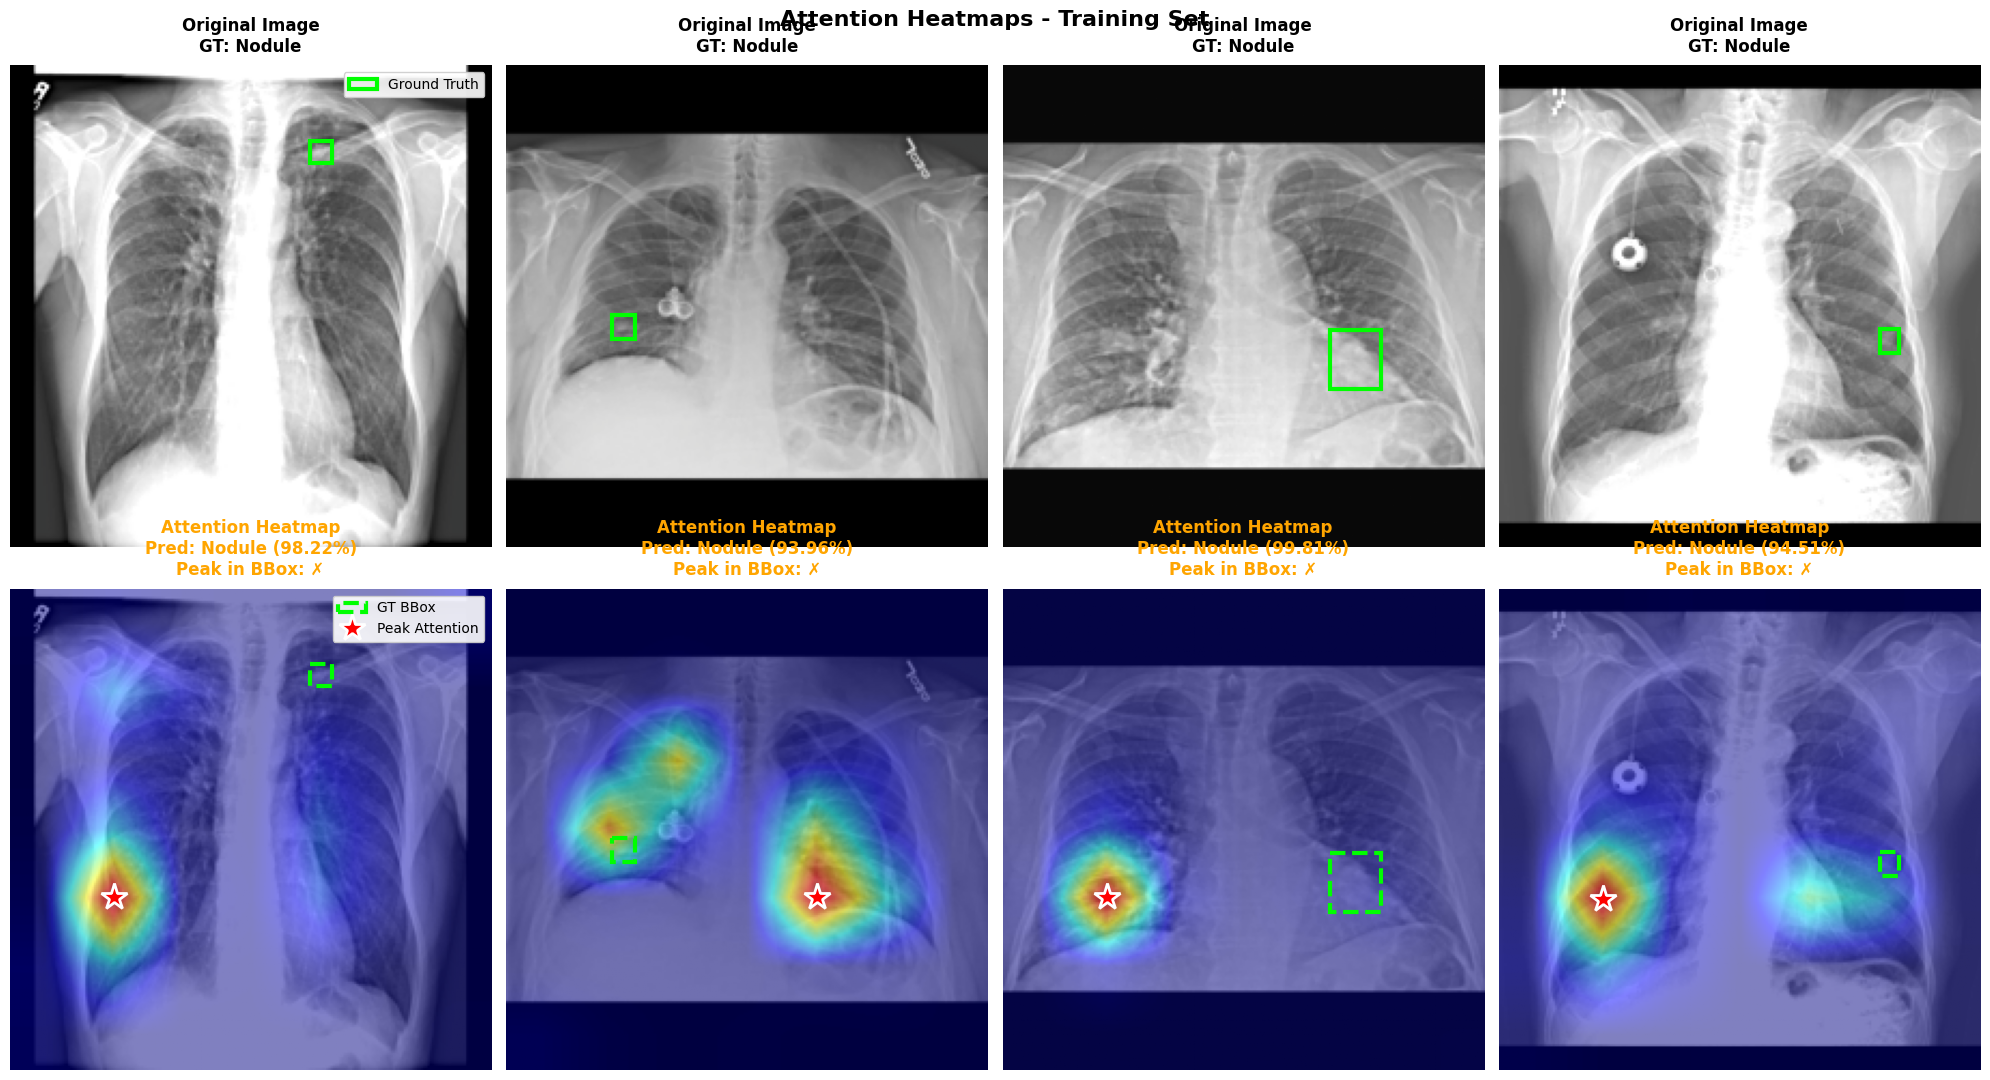


✓ Visualization saved as 'attention_heatmaps_train.png'


In [ ]:
# %% Visualize Attention Heatmaps (FIXED)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

def denormalize_image(img_tensor):
    """Denormalize image from ImageNet normalization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    img = torch.clamp(img, 0, 1)
    return img

def overlay_heatmap(image, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlay heatmap on image
    Args:
        image: RGB numpy array [H, W, 3] in [0, 1]
        heatmap: numpy array [H, W] in [0, 1]
        alpha: transparency
    """
    # Convert image to uint8
    img_uint8 = (image * 255).astype(np.uint8)
    
    # ===== NORMALIZE HEATMAP TO [0, 1] =====
    # This is critical! If all values are near 0, everything will be blue
    heatmap_min = heatmap.min()
    heatmap_max = heatmap.max()
    
    if heatmap_max > heatmap_min:
        heatmap_normalized = (heatmap - heatmap_min) / (heatmap_max - heatmap_min)
    else:
        heatmap_normalized = np.zeros_like(heatmap)
    
    # Convert heatmap to color
    heatmap_uint8 = (heatmap_normalized * 255).astype(np.uint8)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Overlay
    overlayed = cv2.addWeighted(img_uint8, 1-alpha, heatmap_colored, alpha, 0)
    
    return overlayed / 255.0  # Back to [0, 1]

def visualize_attention_heatmaps(model, dataset, device, num_samples=4, save_name='attention_heatmaps.png', dataset_name='Dataset'):
    """Visualize attention heatmaps with ground truth bboxes"""
    model.eval()
    
    # Select samples with nodules for better visualization
    nodule_indices = [i for i in range(len(dataset)) if dataset.df.iloc[i]['label'] == 1]
    if len(nodule_indices) < num_samples:
        indices = np.random.choice(len(dataset), num_samples, replace=False)
    else:
        indices = np.random.choice(nodule_indices, num_samples, replace=False)
    
    fig, axes = plt.subplots(2, num_samples, figsize=(5*num_samples, 11))
    if num_samples == 1:
        axes = axes.reshape(2, 1)
    
    with torch.no_grad():
        for col_idx, sample_idx in enumerate(indices):
            image, label, bbox_gt = dataset[sample_idx]
            
            # Get prediction
            image_batch = image.unsqueeze(0).to(device)
            class_logits, attention_map = model(image_batch, return_attention=True)
            
            # Get classification result
            probs = torch.softmax(class_logits, dim=1)
            pred_class = class_logits.argmax(1).item()
            pred_prob = probs[0, pred_class].item()
            
            # Get attention map
            attention = attention_map.squeeze(0).squeeze(0).cpu().numpy()  # [224, 224]
            
            # ===== DEBUG: Print attention statistics =====
            if col_idx == 0:
                print(f"\nAttention map stats for sample {sample_idx}:")
                print(f"  Min: {attention.min():.6f}")
                print(f"  Max: {attention.max():.6f}")
                print(f"  Mean: {attention.mean():.6f}")
                print(f"  Std: {attention.std():.6f}")
            
            # Denormalize image
            img_display = denormalize_image(image).permute(1, 2, 0).numpy()
            
            # Get bbox coordinates
            bbox_gt_np = bbox_gt.numpy()
            x_gt = bbox_gt_np[0] * IMAGE_SIZE
            y_gt = bbox_gt_np[1] * IMAGE_SIZE
            w_gt = bbox_gt_np[2] * IMAGE_SIZE
            h_gt = bbox_gt_np[3] * IMAGE_SIZE
            
            # === ROW 1: Original + GT BBox ===
            axes[0, col_idx].imshow(img_display)
            
            # Draw ground truth bbox
            rect_gt = patches.Rectangle((x_gt, y_gt), w_gt, h_gt,
                                        linewidth=3, edgecolor='lime', facecolor='none',
                                        label='Ground Truth')
            axes[0, col_idx].add_patch(rect_gt)
            
            class_name = 'Nodule' if label == 1 else 'No Nodule'
            axes[0, col_idx].set_title(f'Original Image\nGT: {class_name}', 
                                       fontsize=12, fontweight='bold', pad=10)
            axes[0, col_idx].axis('off')
            
            if col_idx == 0:
                axes[0, col_idx].legend(loc='upper right', fontsize=10, framealpha=0.9)
            
            # === ROW 2: Heatmap Overlay + BBox ===
            overlayed = overlay_heatmap(img_display, attention, alpha=0.5)
            axes[1, col_idx].imshow(overlayed)
            
            # Draw ground truth bbox on heatmap
            rect_gt2 = patches.Rectangle((x_gt, y_gt), w_gt, h_gt,
                                         linewidth=3, edgecolor='lime', facecolor='none',
                                         linestyle='--', label='GT BBox')
            axes[1, col_idx].add_patch(rect_gt2)
            
            # Check if attention peak is inside bbox (pointing game)
            attention_peak_y, attention_peak_x = np.unravel_index(attention.argmax(), attention.shape)
            inside_bbox = (x_gt <= attention_peak_x <= x_gt + w_gt) and (y_gt <= attention_peak_y <= y_gt + h_gt)
            
            # Mark attention peak
            axes[1, col_idx].plot(attention_peak_x, attention_peak_y, 'r*', markersize=20, 
                                 markeredgecolor='white', markeredgewidth=2, label='Peak Attention')
            
            pred_name = 'Nodule' if pred_class == 1 else 'No Nodule'
            title_color = 'green' if pred_class == label and inside_bbox else 'orange' if pred_class == label else 'red'
            
            title = f'Attention Heatmap\n'
            title += f'Pred: {pred_name} ({pred_prob:.2%})\n'
            title += f'Peak in BBox: {"✓" if inside_bbox else "✗"}'
            
            axes[1, col_idx].set_title(title, fontsize=12, fontweight='bold', 
                                       color=title_color, pad=10)
            axes[1, col_idx].axis('off')
            
            if col_idx == 0:
                axes[1, col_idx].legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    fig.suptitle(f'Attention Heatmaps - {dataset_name}', fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Visualization saved as '{save_name}'")

# Test it
print("\n" + "="*70)
print("VISUALIZING ATTENTION HEATMAPS ON TRAINING SET")
print("="*70)
visualize_attention_heatmaps(model, train_dataset, device, num_samples=4, 
                            save_name='attention_heatmaps_train.png',
                            dataset_name='Training Set')


VISUALIZING ATTENTION HEATMAPS ON TRAINING SET

Attention map stats for sample 2671:
  Min: 0.000001
  Max: 0.012855
  Mean: 0.001567
  Std: 0.002089


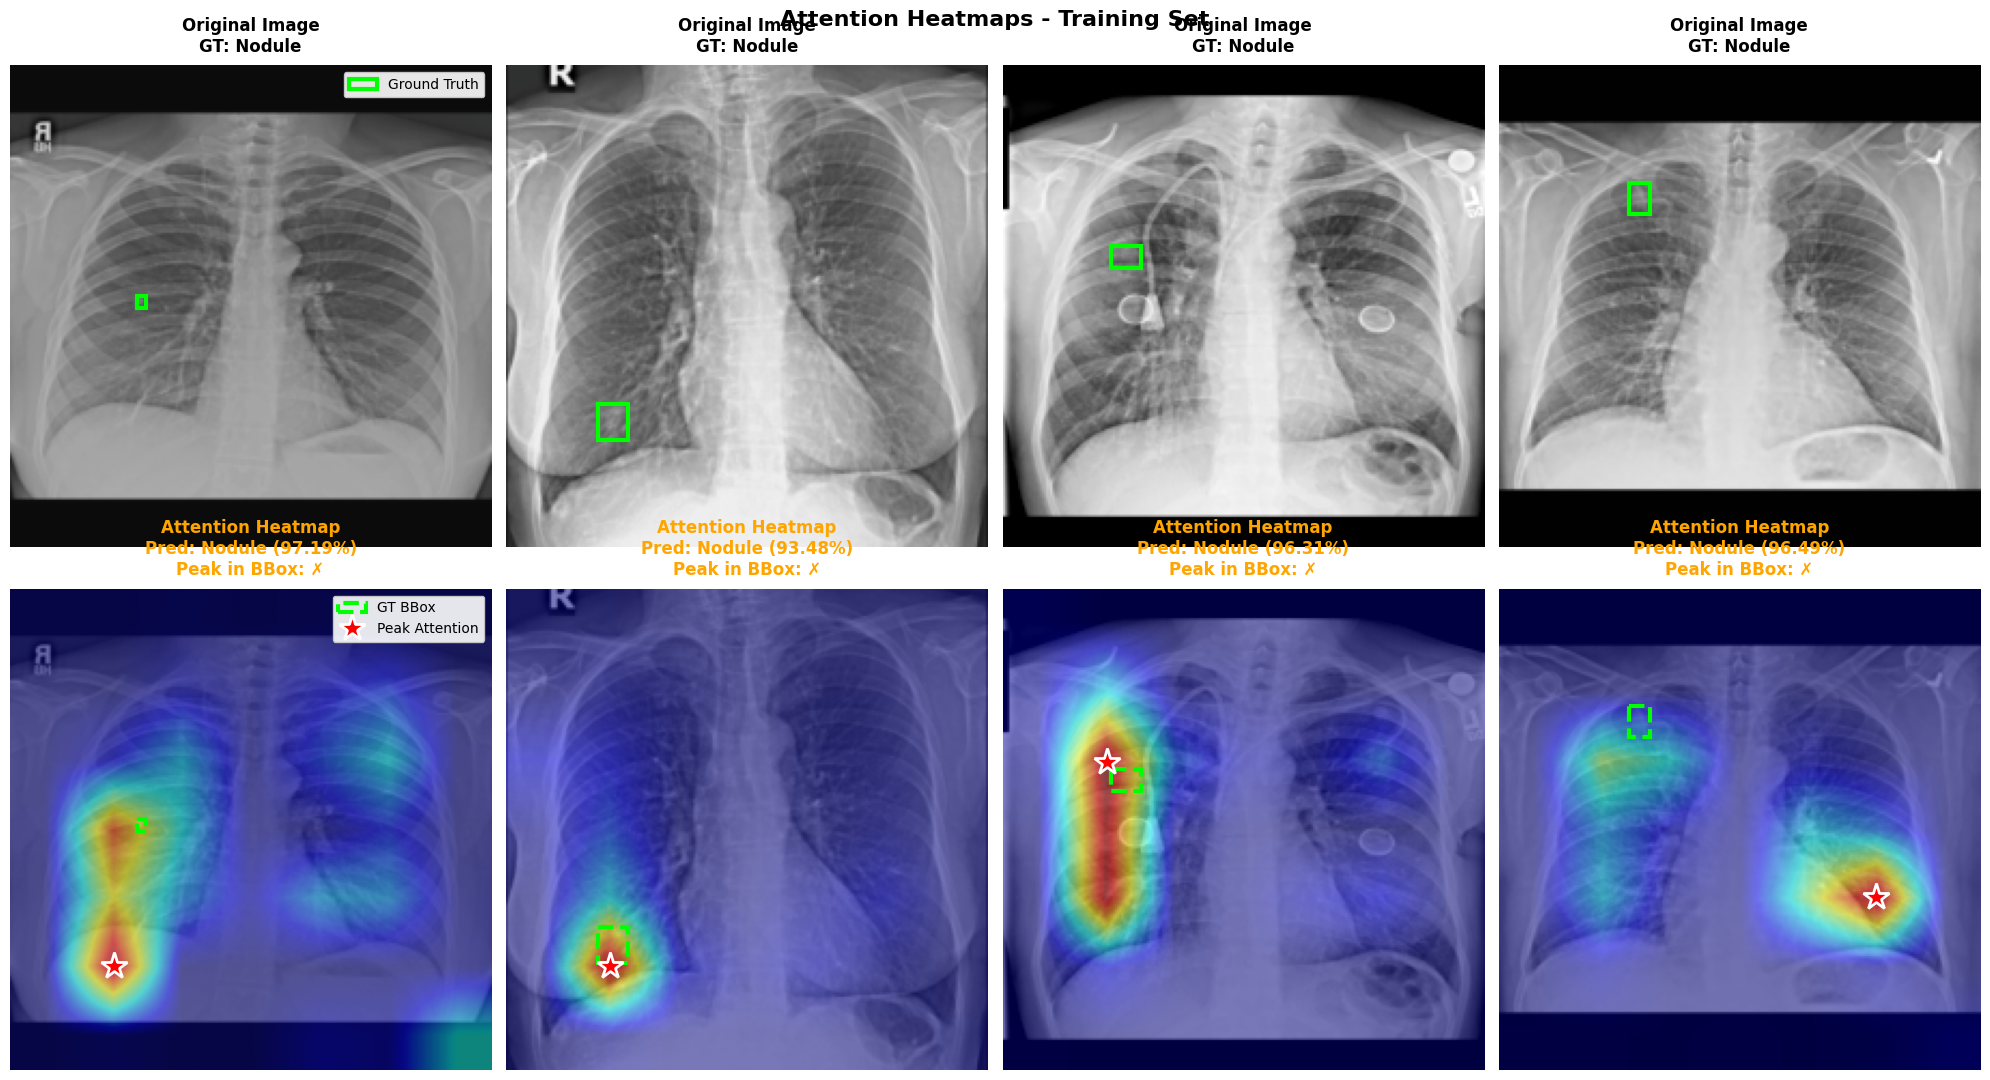


✓ Visualization saved as 'attention_heatmaps_train.png'

VISUALIZING ATTENTION HEATMAPS ON VALIDATION SET

Attention map stats for sample 90:
  Min: 0.000000
  Max: 0.022618
  Mean: 0.002568
  Std: 0.003909


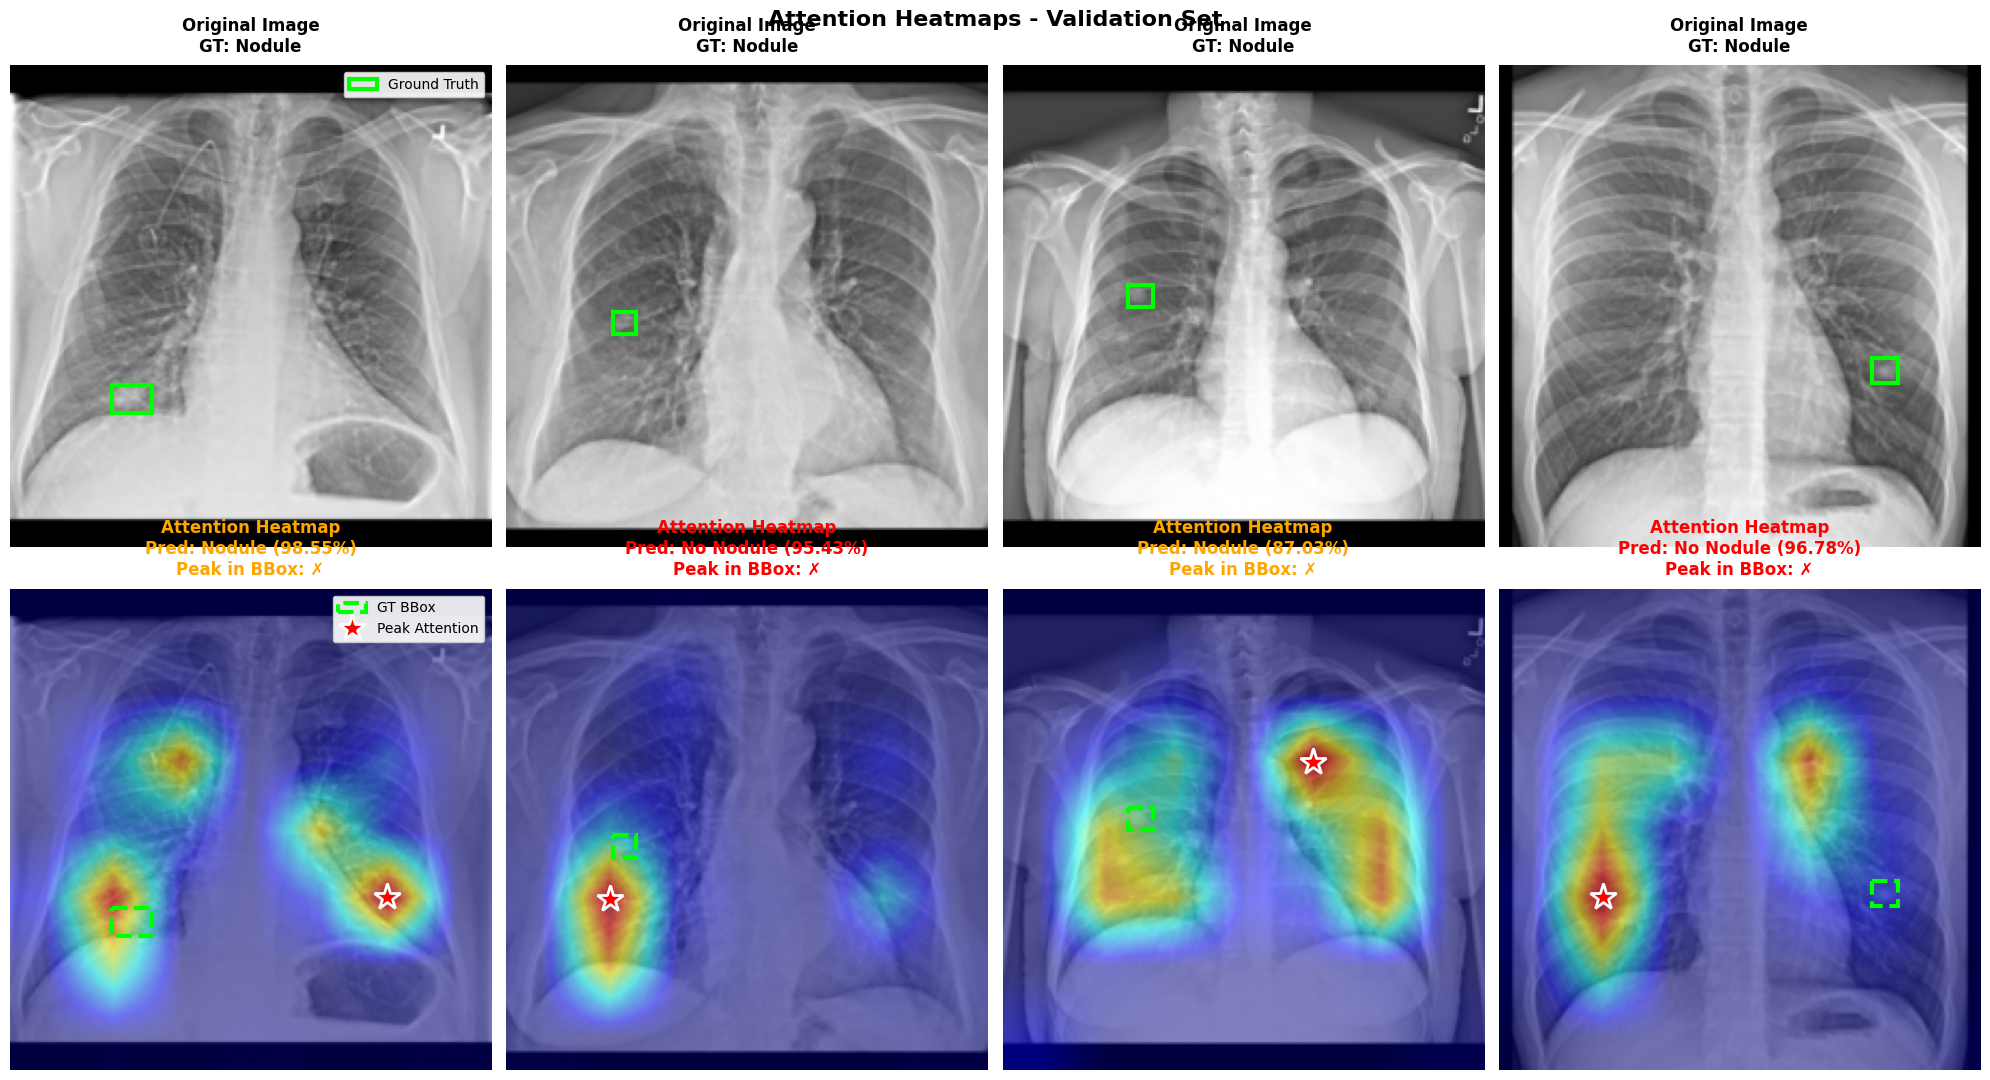


✓ Visualization saved as 'attention_heatmaps_val.png'

VISUALIZING ATTENTION HEATMAPS ON TEST SET

Attention map stats for sample 140:
  Min: 0.000000
  Max: 0.033233
  Mean: 0.002212
  Std: 0.003918


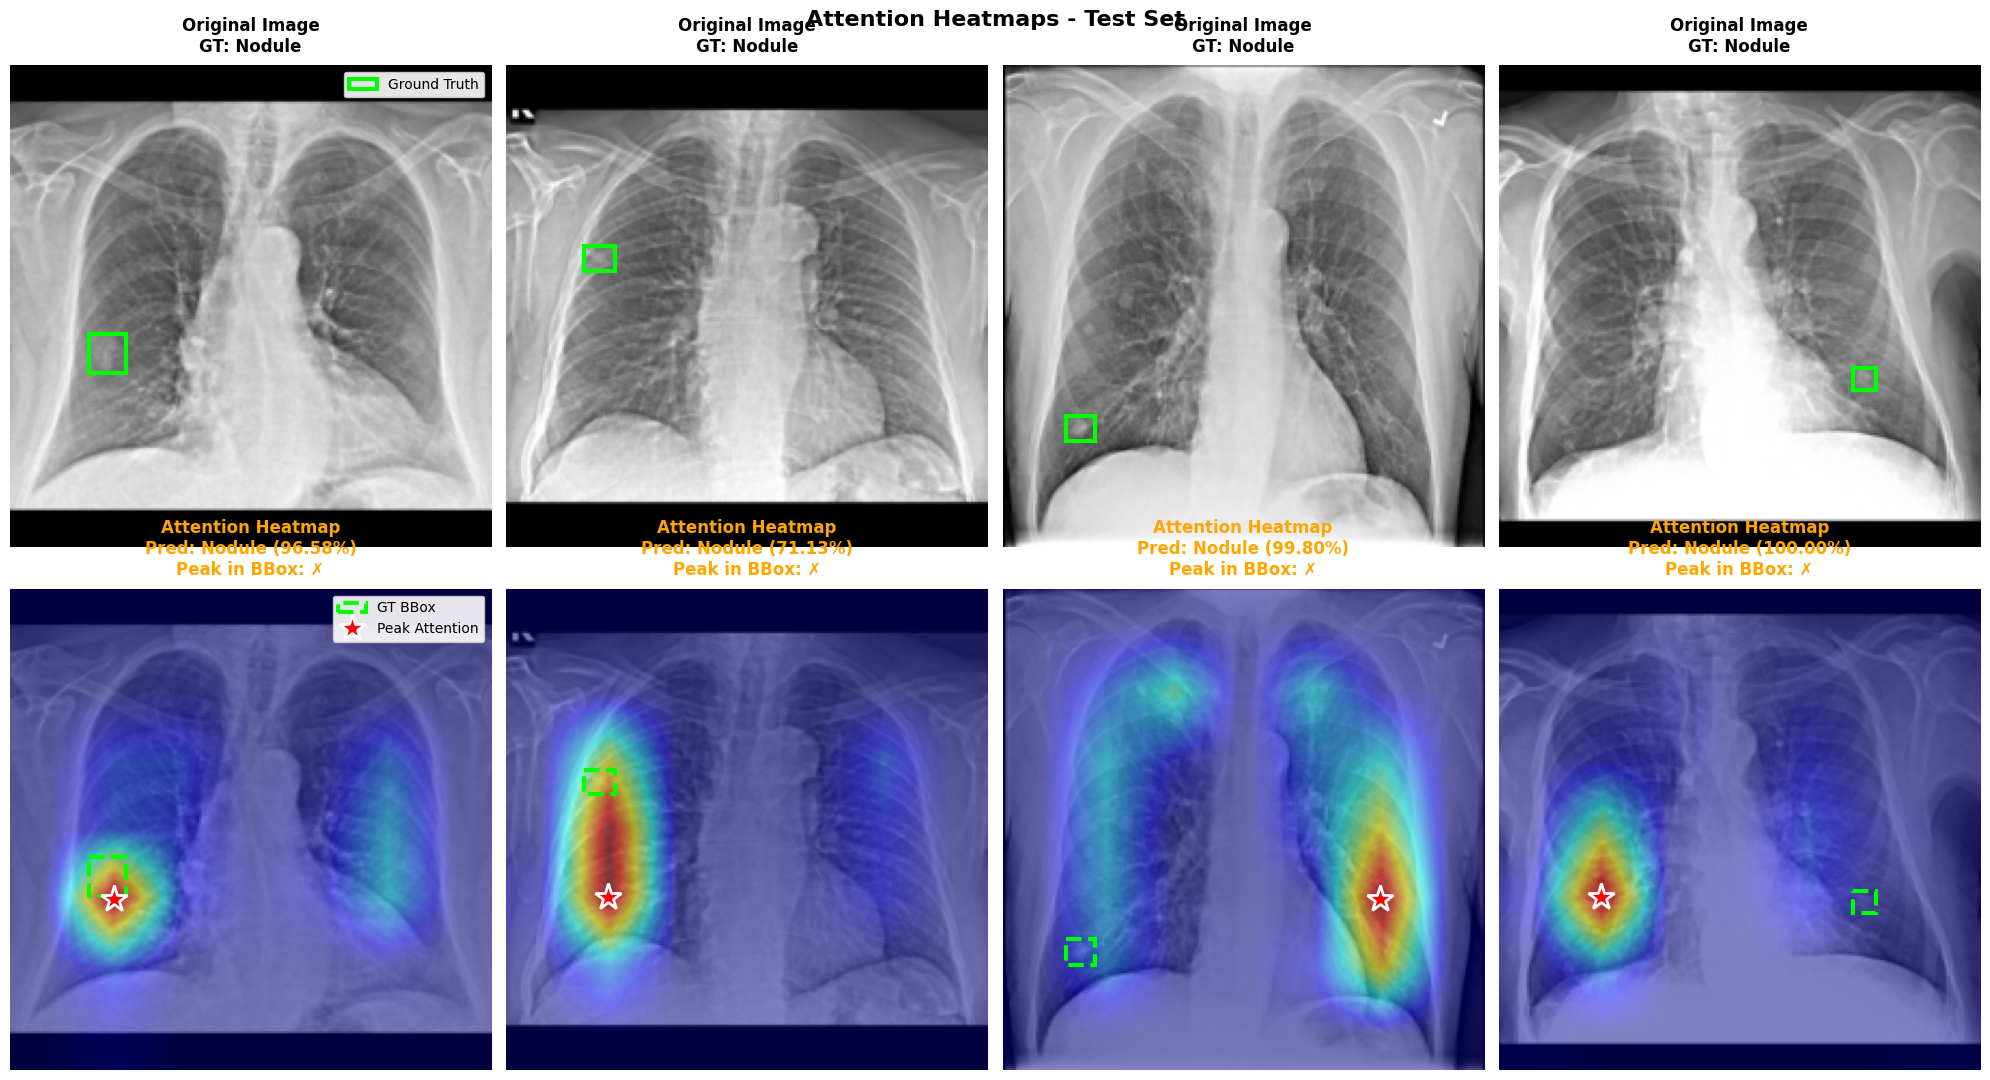


✓ Visualization saved as 'attention_heatmaps_test.png'


In [ ]:
# ===== Visualize on TRAINING SET =====
print("\n" + "="*70)
print("VISUALIZING ATTENTION HEATMAPS ON TRAINING SET")
print("="*70)
visualize_attention_heatmaps(model, train_dataset, device, num_samples=4, 
                            save_name='attention_heatmaps_train.png',
                            dataset_name='Training Set')

# ===== Visualize on VALIDATION SET =====
print("\n" + "="*70)
print("VISUALIZING ATTENTION HEATMAPS ON VALIDATION SET")
print("="*70)
visualize_attention_heatmaps(model, val_dataset, device, num_samples=4, 
                            save_name='attention_heatmaps_val.png',
                            dataset_name='Validation Set')

# ===== Visualize on TEST SET =====
print("\n" + "="*70)
print("VISUALIZING ATTENTION HEATMAPS ON TEST SET")
print("="*70)
visualize_attention_heatmaps(model, test_dataset, device, num_samples=4, 
                            save_name='attention_heatmaps_test.png',
                            dataset_name='Test Set')

In [ ]:
# %% Compute Pointing Game Accuracy on Test Set
print("\n" + "="*60)
print("COMPUTING POINTING GAME ACCURACY ON TEST SET")
print("="*60)

model.eval()
total_nodules = 0
correct_pointing = 0

with torch.no_grad():
    for images, labels, bboxes in tqdm(test_loader, desc='Computing PG Accuracy'):
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        
        class_logits, attention_map = model(images, return_attention=True)
        
        # Only evaluate on nodule samples
        positive_mask = (labels == 1)
        if positive_mask.sum() == 0:
            continue
        
        for i in range(images.size(0)):
            if not positive_mask[i]:
                continue
            
            total_nodules += 1
            
            # Get attention peak
            attention = attention_map[i, 0].cpu().numpy()
            peak_y, peak_x = np.unravel_index(attention.argmax(), attention.shape)
            
            # Get bbox
            bbox = bboxes[i].cpu().numpy()
            x_gt = bbox[0] * IMAGE_SIZE
            y_gt = bbox[1] * IMAGE_SIZE
            x2_gt = x_gt + bbox[2] * IMAGE_SIZE
            y2_gt = y_gt + bbox[3] * IMAGE_SIZE
            
            # Check if peak is inside bbox
            if x_gt <= peak_x <= x2_gt and y_gt <= peak_y <= y2_gt:
                correct_pointing += 1

pointing_game_acc = 100.0 * correct_pointing / total_nodules if total_nodules > 0 else 0.0

print(f"\nPointing Game Results:")
print(f"  Total nodules: {total_nodules}")
print(f"  Correct pointing: {correct_pointing}")
print(f"  Pointing Game Accuracy: {pointing_game_acc:.2f}%")


COMPUTING POINTING GAME ACCURACY ON TEST SET


Computing PG Accuracy: 100%|██████████| 50/50 [00:12<00:00,  4.01it/s]


Pointing Game Results:
  Total nodules: 217
  Correct pointing: 7
  Pointing Game Accuracy: 3.23%
